In [5]:
def mean(data: list):
    sum = 0
    for num in data:
        sum+=num
    return sum/len(data)

def variance(data: list):
    mean1 = mean(data)
    sum = 0
    for num in data:
        sum += (num - mean1) ** 2
    return sum/len(data)

def standard_deviation(data: list):
    return (variance(data))**0.5

def sample_variance(data: list):
    mean1 = mean(data)
    sum = 0
    for num in data:
        sum += (num - mean1) ** 2
    return sum/(len(data)-1)

def sample_standard_deviation(data: list):
    return sample_variance(data) ** 0.5

data1 = [7,8,9,10,11]
print(mean(data1))
print(standard_deviation(data1))


9.0
1.4142135623730951


In [6]:
def median(data:list):
    data.sort()
    if len(data) % 2 == 0:
        return (data[len(data)//2-1] + data[len(data)//2])/2
    else:
        return data[len(data)//2]

def iqr(data:list):
    if len(data) % 2 == 0:
        f_data = data[:len(data)//2]
        s_data = data[len(data)//2:]
        return median(s_data) - median(f_data)
    else:
        f_data = data[:len(data)//2]
        s_data = data[len(data)//2+1:]
        return median(s_data) - median(f_data)
    
data2 = [0,1.5,2.5,3,4,4,4,7,7.5]
print(median(data2))
print(iqr(data2))

4
3.5


In [7]:
def mad(data:list):
    mean1 = mean(data)
    sum = 0
    for num in data:
        sum += abs(num-mean1)
    return sum/len(data)

print(mad([4,6,8,10]))

2.0


In [8]:
table1 = {"x": [1, 2, 2, 3],
         "y": [1, 2, 3, 6]}

def cor_coef(table):
    x_mean = mean(table["x"])
    y_mean = mean(table["y"])
    s_x = sample_standard_deviation(table["x"])
    s_y = sample_standard_deviation(table["y"])
    
    sum = 0
    for i in range(len(table["x"])):
       sum += ((table["x"][i] - x_mean)/s_x) * ((table["y"][i] - y_mean)/s_y)
    return sum / (len(table["x"])-1)


cor_coef(table1)
    

0.9449111825230679

In [9]:
# y = mx + b
# m = r * s_y /  s_x

def equation_line(table):
    x_mean = mean(table["x"])
    y_mean = mean(table["y"])
    s_x = sample_standard_deviation(table["x"])
    s_y = sample_standard_deviation(table["y"])
    r = cor_coef(table)

    m = r * s_y / s_x
    b = y_mean - m * x_mean
    
    return m,b

equation_line(table1)
    

(2.5, -2.0)

In [10]:

x_mean = 10.2
y_mean = 37.6
s_x = 2.8
s_y = 30.8
r = -0.98

m = r * s_y / s_x
b = y_mean - m * x_mean

print(f"y={m}x{b if b < 0 else f"+{b}"}")

y=-10.780000000000001x+147.556


In [11]:
def residuals(table):
    eq = equation_line(table)
    arr = []
    for i in range(len(table["x"])):
        arr.append(table["y"][i] - (table["x"][i]*eq[0] + eq[1]))
    return arr

# Standard deviation of residuals
def rmsd(table):
    residuals1 = residuals(table1)
    sum = 0
    for num in residuals1:
        sum += num ** 2
    return (sum / (len(residuals1)-1))** 0.5

rmsd(table1)

0.7071067811865476

In [12]:
import numpy as np
def equation_line2(table):
    x_mean = mean(table["x"])
    y_mean = mean(table["y"])
    xy_mean = mean(table["x"] * table["y"])
    x_squared_mean = mean(table["x"] * table["x"])
    
    m = (x_mean*y_mean - xy_mean)/(x_mean**2 - x_squared_mean)
    b = y_mean - m * x_mean
    return m,b


table_x = np.array([-2,-1,1,4])
table_y = np.array([-3,-1,2,3])
table2 = {"x": table_x,
          "y": table_y}

m, b = equation_line2(table2)

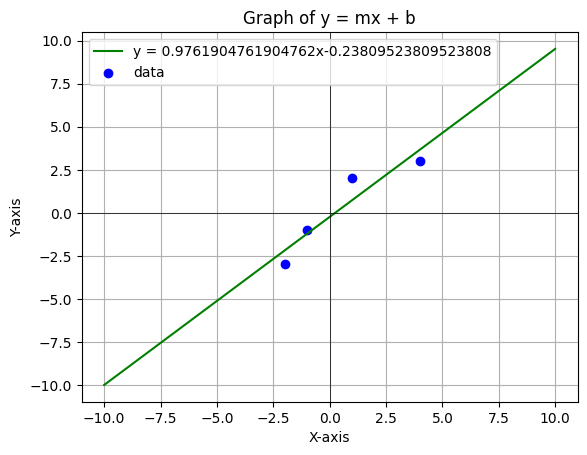

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Generate x values
x = np.linspace(-10, 10, 100)  # from -10 to 10
# Calculate y values based on y = mx + b
y = m * x + b

# Create the plot
plt.plot(x, y, label=f"y = {m}x{b}", color="green")

plt.scatter(table_x, table_y, label="data", color="blue")
# Add labels and title
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Graph of y = mx + b")
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)  # x-axis
plt.axvline(0, color='black', linewidth=0.5)  # y-axis
plt.legend()

# Show the graph
plt.show()


In [ ]:
table_x = np.array([-2,-1,1,4])
table_y = np.array([-3,-1,2,3])
table2 = {"x": table_x,
          "y": table_y}

# Standard error
def SE_line(table):
    m,b = equation_line2(table)
    sum = 0
    
    for i in range(len(table["x"])):
        sum += (table["y"][i] - (table["x"][i]*m + b))**2
    return sum

def SE_y(table):
    y_mean = mean(table["y"])
    sum = 0
    for i in range(len(table["y"])):
        sum += (table["y"][i] - y_mean)**2
    return sum

print(1-SE_line(table2)/SE_y(table2))
print(cor_coef(table2)**2)

0.879644165358451
0.8796441653584509


In [15]:
import random

one = 0
two = 0
for i in range(1000000):
    if random.randint(1,2) == 1:
        one += 1
    else:
        two += 1
print(one, two)

500418 499582


In [16]:
# The monty hall problem
from random import randint

res = {"w": 0,
       "l": 0}

for i in range(1000):

    mas = [0,0,0]
    mas[randint(0,2)] = 1


    if mas[randint(0,2)] == 1:
        res["w"] += 1
    else:
        res["l"] += 1

f"{res["w"]/(res["w"]+res["l"])*100}%"


'32.7%'

In [17]:
# The monty hall problem
from random import randint

res = {"w": 0,
       "l": 0}

for i in range(1000):

    mas = [0,0,0]
    prise = randint(0,2)
    mas[prise] = 1
    
    user = randint(0,2)
    
    if user == prise:
        res["l"] += 1
    # else:
    #   res["w"] += 1
    elif user == 0 and (prise == 1 or prise == 2):
        res["w"] += 1
    elif user == 1 and (prise == 0 or prise == 2):
        res["w"] += 1
    elif user == 2 and (prise == 0 or prise == 2):
        res["w"] += 1

f"{res["w"]/(res["w"]+res["l"])*100}%"

'61.25000000000001%'

In [18]:
a = set([5,3,4])
b = set([5,7,3])

print(a - a)

set()


In [19]:
from math import factorial

# Binomial coefficient
def combination(n,r):
    return factorial(n)/(factorial(r)*factorial(n-r))

def permutation(n,r):
    return factorial(n)/factorial(n-r)

permutation(24,4)
combination(8,2)


28.0

In [20]:

def binompdf(n,p,s):
    return combination(n,s) * p ** s * (1-p) ** (n-s)

def binomcdf(n,p,s):
    sum = 0
    for i in range(s+1):
        sum += combination(n,i) * p ** i * (1-p) ** (n-i)
    return sum

binompdf(4,0.1,2)


0.04860000000000001

In [21]:
def binom_expected_value(n,p):
    return n*p

def binom_variance(n,p):
    return n*p(1-p)

In [22]:
def geometpdf(p,s):
    return (1-p)**(s-1)*p

def geometcdf(p,s):
    return 1 - ((1-p)**s)

print(1-geometcdf(0.15,5))

0.4437053124999999


In [23]:
def geomet_expected_value(p):
    return 1/p

In [1]:
def expected_value(table: dict):
    sum = 0
    for i in range(len(table["x"])):
        sum += table["x"][i] * table["P(x)"][i]
    print(f"mean: {sum}")
    return sum

def standard_deviation_rand_var(table):
    sum = 0
    mean1 = expected_value(table)
    for i in range(len(table["x"])):
        sum += (table["x"][i]-mean1)**2 * table["P(x)"][i]
    print(f"variance: {sum}")
    sum = sum ** 0.5
    print(f"standard deviation: {sum}")
    return sum

table_prob = {"x": [-100, 10000],
              "P(x)": [31/32,1/32]}

standard_deviation_rand_var(table_prob)

mean: 215.625
variance: 3088193.359375
standard deviation: 1757.3256270182258


1757.3256270182258

In [9]:
# sampling_distributions_standard_deviation

def sampling_distributions_stdev(n,p):
    return (p*(1-p)/n)**0.5
    
sigma1 = sampling_distributions_stdev(120,0.85)
sigma1

0.03259601202601325

In [16]:
# z-score table
from scipy.stats import norm

# (x-x_mean)/standard_deviation

# z = (0.8-0.85)/sigma1

z = -1.64
output = norm.cdf(z)
print(f"Z-table value for z = {z}: {output:.5f}")

1-output
# 0.93748

Z-table value for z = -1.64: 0.05050


np.float64(0.9494974165258963)

In [ ]:
import math
x = -1.000001
x/(10*(math.sin(x+1)**2))

-100000100016.48668

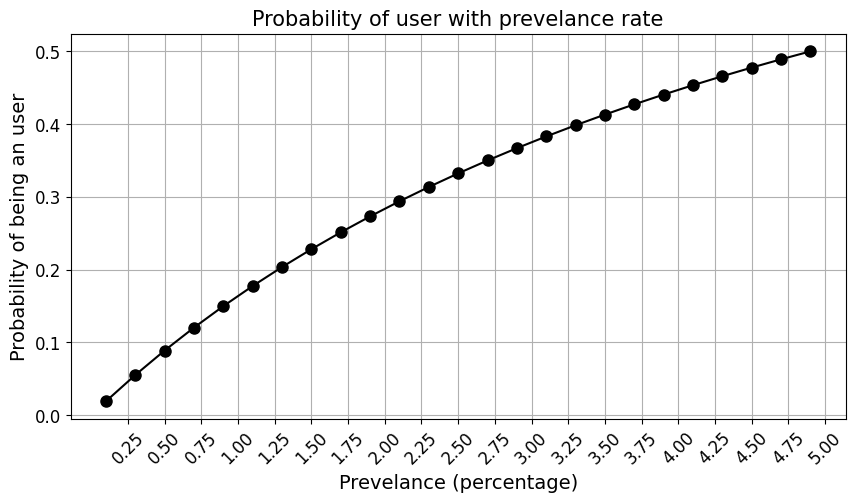

In [ ]:
import matplotlib.pyplot as plt

def drug_user(
        prob_th=0.5,
        sensitivity=0.99,
        specificity=0.99,
        prevelance=0.01,
        verbose=True):
    """
    Computes the posterior using Bayes' rule
    """
    p_user = prevelance
    p_non_user = 1-prevelance
    p_pos_user = sensitivity
    p_neg_user = specificity
    p_pos_non_user = 1-specificity
    
    num = p_pos_user*p_user
    den = p_pos_user*p_user+p_pos_non_user*p_non_user
    
    prob = num/den
    
    if verbose:
        if prob > prob_th:
            print("The test-taker could be an user")
        else:
            print("The test-taker may not be an user")

    return prob

ps = []
pres = []
for pre in [i*0.001 for i in range(1,51,2)]:
    pres.append(pre*100)
    p = drug_user(prob_th=0.5,sensitivity=0.97,specificity=0.95,prevelance=pre,verbose=False)
    ps.append(p)

plt.figure(figsize=(10,5))
plt.title("Probability of user with prevelance rate",fontsize=15)
plt.plot(pres,ps,color='k',marker='o',markersize=8)
plt.grid(True)
plt.xlabel("Prevelance (percentage)",fontsize=14)
plt.ylabel("Probability of being an user",fontsize=14)
plt.xticks([i*0.25 for i in range(1,21)],fontsize=12,rotation=45)
plt.yticks(fontsize=12)
plt.show()